# Feature engineering — choosing meteorology–pollution lags

This tutorial shows how to pick the lags that link meteorology to pollution in a
**data-driven** way, using `normet.analyze_lag` (ACF / PACF + pre-whitened CCF),
and how to turn the result into model features with `normet.add_lag_features`.

The lags you pass to `add_lag_features` are a modelling choice — `analyze_lag`
helps you make it from the data instead of by hand.

# 0. Setup

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9, 4)

import normet as nm

# 1. Data: load

We use the same Marylebone Road (MY1) hourly dataset as the other tutorials:
co-located air quality and meteorology for 2020. We rename `PM2.5` to `pm25`
for convenience.

In [2]:
from _synth import make_my1_data

my1 = make_my1_data().rename(columns={"PM2.5": "pm25"})
my1 = my1.sort_values('date').reset_index(drop=True)
my1[["date", "pm25", "ws", "blh", "t2m", "tp"]].head()

,date,pm25,ws,blh,t2m,tp
0,2020-01-01 00:00:00,58.1,2.1,384.209053,278.394725,0.000008
1,2020-01-01 01:00:00,43.2,2.1,353.220263,277.772899,0.000002
2,2020-01-01 02:00:00,43.0,2.3,255.911846,277.463419,0.000005
3,2020-01-01 03:00:00,42.8,1.8,191.375560,277.305813,0.000005
4,2020-01-01 04:00:00,36.8,1.7,151.780210,277.478941,0.000003


# 2. Target lag structure (ACF / PACF)

Call `analyze_lag` with only a `target` to inspect the pollutant's own memory.
The **ACF** shows how slowly autocorrelation decays; the **PACF** isolates the
*direct* lags and is what we use to suggest autoregressive lags of the target.

Lag diagnostics for target='pm25'
  n=6373, significance band=±0.025 (alpha=0.05)
  suggested target AR lags (PACF): [1, 2, 9, 10, 14, 15, 16, 17, 18, 19, 21, 26, 27, 28, 29, 42]


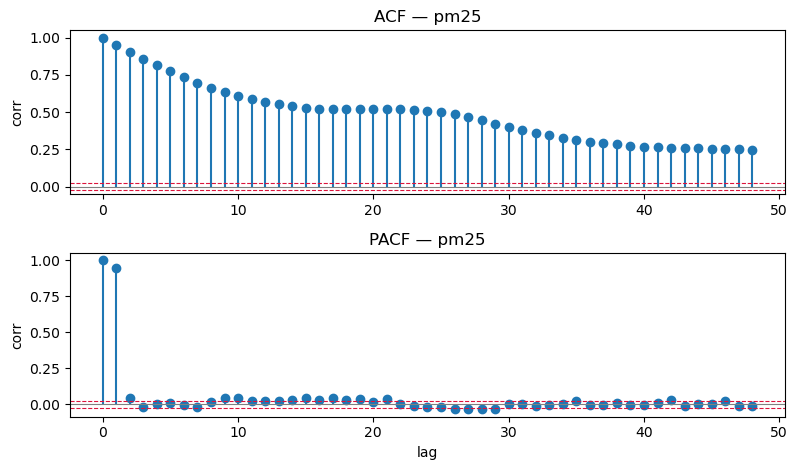

In [3]:
target_diag = nm.analyze_lag(my1, target="pm25", max_lag=48)
print(target_diag.summary())
target_diag.plot()
plt.tight_layout()

`target_ar_lags` lists the PACF lags that cross the significance band — good
candidates to add as `pm25` autoregressive features.

In [4]:
target_diag.target_ar_lags

[1, 2, 9, 10, 14, 15, 16, 17, 18, 19, 21, 26, 27, 28, 29, 42]

# 3. Driver → pollutant lag: why pre-whitening matters

Now add a meteorological `driver`. Wind speed and PM2.5 both carry a strong
diurnal cycle, so a **naive** cross-correlation is dominated by that shared
seasonality and lights up at many lags. **Pre-whitening** (the default) filters
that structure out before computing the CCF, leaving a credible lead–lag.

In [5]:
raw = nm.analyze_lag(my1, target="pm25", driver="ws", max_lag=48, prewhiten=False)
pw  = nm.analyze_lag(my1, target="pm25", driver="ws", max_lag=48, prewhiten=True)

print(f"raw CCF          : {len(raw.driver_lags):>2d} significant lags, peak={raw.peak_lag}")
print(f"pre-whitened CCF : {len(pw.driver_lags):>2d} significant lags, peak={pw.peak_lag}")

raw CCF          : 49 significant lags, peak=2
pre-whitened CCF : 11 significant lags, peak=4


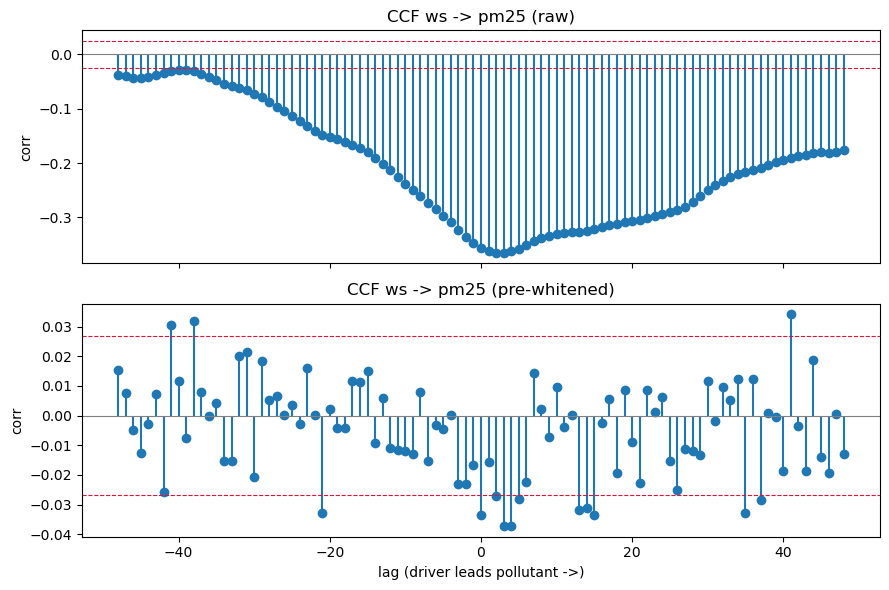

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
for ax, res, title in [(axes[0], raw, "raw"), (axes[1], pw, "pre-whitened")]:
    ax.stem(res.ccf["lag"], res.ccf["value"], basefmt=" ")
    ax.axhline(0, color="0.5", lw=0.8)
    ax.axhline(res.band, color="crimson", ls="--", lw=0.8)
    ax.axhline(-res.band, color="crimson", ls="--", lw=0.8)
    ax.set_title(f"CCF ws -> pm25 ({title})")
    ax.set_ylabel("corr")
axes[1].set_xlabel("lag (driver leads pollutant ->)")
plt.tight_layout()

The raw panel is a forest of spurious peaks; the pre-whitened panel concentrates
the signal at a small set of short lags. `peak_lag` (here for `ws`) is the
driver-leading lag with the largest absolute CCF. Its sign convention matches
`add_lag_features` exactly: `peak_lag = k` means `ws.shift(k)` is the predictor.

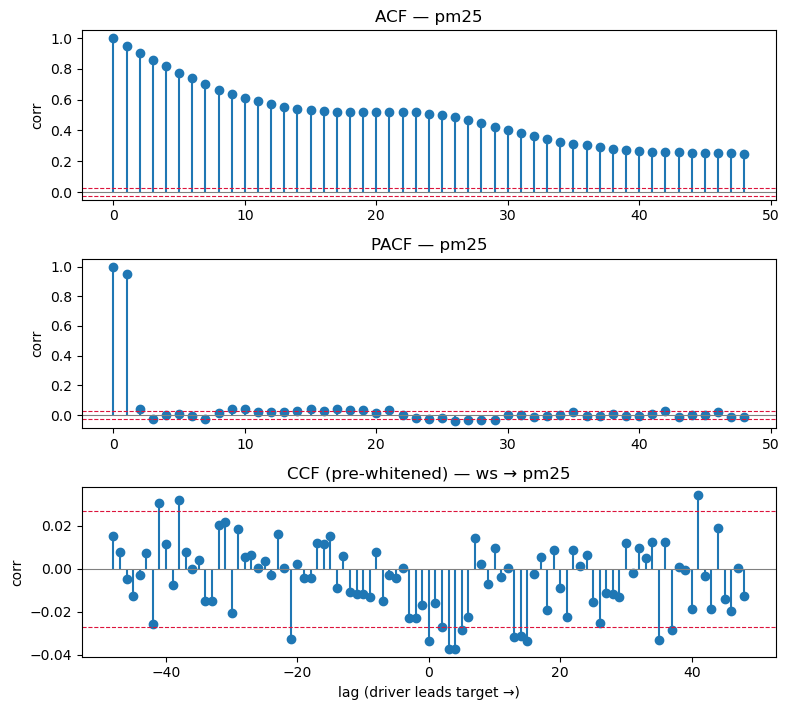

In [7]:
pw.plot()
plt.tight_layout()

# 4. Assemble lags across several drivers

Run `analyze_lag` once per meteorological driver to build the lag set for each.
A CCF lag of `0` means a *contemporaneous* effect (the raw column already in the
frame), so for **lagged** features we keep the significant **positive**
driver-leading lags, capping the count so the feature matrix stays manageable.

In [8]:
drivers = ["ws", "blh", "t2m", "tp", "sp"]

rows, lag_plan = [], {}
for drv in drivers:
    res = nm.analyze_lag(my1, target="pm25", driver=drv, max_lag=48, prewhiten=True)
    pos = [k for k in res.driver_lags if k > 0]          # drop lag 0 (contemporaneous)
    lags = (pos or ([res.peak_lag] if res.peak_lag else []))[:4]
    lag_plan[drv] = lags
    rows.append({"driver": drv, "peak_lag": res.peak_lag,
                 "contemporaneous": 0 in res.driver_lags,
                 "n_significant": len(res.driver_lags), "lags_used": lags})

pd.DataFrame(rows)

,driver,peak_lag,contemporaneous,n_significant,lags_used
0,ws,4,True,11,"[2, 3, 4, 5]"
1,blh,1,False,7,"[1, 3, 7, 13]"
2,t2m,5,False,3,"[1, 5, 17]"
3,tp,0,True,5,"[1, 4, 42, 45]"
4,sp,3,False,3,"[3, 45, 48]"


# 5. Build the lag features

Feed the plan to `add_lag_features`. Each driver gets `{col}_lag{k}` columns; we
also add the target's own autoregressive lags from step 2.

In [9]:
df_feat = my1.copy()
for drv, lags in lag_plan.items():
    if lags:
        df_feat = nm.add_lag_features(df_feat, cols=[drv], lags=lags)

ar_lags = target_diag.target_ar_lags[:4] or [1]
df_feat = nm.add_lag_features(df_feat, cols=["pm25"], lags=ar_lags)

new_cols = [c for c in df_feat.columns if "_lag" in c]
print(f"added {len(new_cols)} lag features:")
print(new_cols)
df_feat[["date", "pm25"] + new_cols].head()

added 22 lag features:
['ws_lag2', 'ws_lag3', 'ws_lag4', 'ws_lag5', 'blh_lag1', 'blh_lag3', 'blh_lag7', 'blh_lag13', 't2m_lag1', 't2m_lag5', 't2m_lag17', 'tp_lag1', 'tp_lag4', 'tp_lag42', 'tp_lag45', 'sp_lag3', 'sp_lag45', 'sp_lag48', 'pm25_lag1', 'pm25_lag2', 'pm25_lag9', 'pm25_lag10']


,date,pm25,ws_lag2,ws_lag3,ws_lag4,ws_lag5,blh_lag1,blh_lag3,blh_lag7,blh_lag13,...,tp_lag4,tp_lag42,tp_lag45,sp_lag3,sp_lag45,sp_lag48,pm25_lag1,pm25_lag2,pm25_lag9,pm25_lag10
0,2020-01-01 00:00:00,58.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-01 01:00:00,43.2,NaN,NaN,NaN,NaN,384.209053,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,58.1,NaN,NaN,NaN
2,2020-01-01 02:00:00,43.0,2.1,NaN,NaN,NaN,353.220263,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,43.2,58.1,NaN,NaN
3,2020-01-01 03:00:00,42.8,2.1,2.1,NaN,NaN,255.911846,384.209053,NaN,NaN,...,NaN,NaN,NaN,102252.303312,NaN,NaN,43.0,43.2,NaN,NaN
4,2020-01-01 04:00:00,36.8,2.3,2.1,2.1,NaN,191.375560,353.220263,NaN,NaN,...,0.000008,NaN,NaN,102211.168636,NaN,NaN,42.8,43.0,NaN,NaN


These lag columns can now go straight into `feature_names` for
`nm.train_model` / `nm.do_all`. The learner (LightGBM / FLAML) does the final
selection via feature importance, but starting from CCF-justified lags keeps the
candidate set small and physically meaningful.

For multi-site panels, call `analyze_lag` once per site (pass a single-site
slice) and `add_lag_features(..., group_col="site")` so lags don't bleed across
stations.